In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = {
    'Age':[18,19,20,21,22]*10,
    'StudyHours':[2,3,4,5,6]*10,
    'Attendance':[60,70,80,90,95]*10,
    'Pass':[0,0,1,1,1]*10
}

df = pd.DataFrame(data)

df.to_csv("student_data.csv", index=False)

df.head()

,Age,StudyHours,Attendance,Pass
0,18,2,60,0
1,19,3,70,0
2,20,4,80,1
3,21,5,90,1
4,22,6,95,1


In [ ]:
df = pd.read_csv("student_data.csv")
df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         50 non-null     int64
 1   StudyHours  50 non-null     int64
 2   Attendance  50 non-null     int64
 3   Pass        50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


In [ ]:
df.describe()

,Age,StudyHours,Attendance,Pass
count,50.000000,50.000000,50.000000,50.000000
mean,20.000000,4.000000,79.000000,0.600000
std,1.428571,1.428571,12.936264,0.494872
min,18.000000,2.000000,60.000000,0.000000
25%,19.000000,3.000000,70.000000,0.000000
50%,20.000000,4.000000,80.000000,1.000000
75%,21.000000,5.000000,90.000000,1.000000
max,22.000000,6.000000,95.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,0
StudyHours,0
Attendance,0
Pass,0


## Model Training

The dataset was prepared for machine learning by separating input features and target labels. A Random Forest Classifier was selected for classification because of its reliability and strong predictive performance.

In [ ]:
X = df[['Age','StudyHours','Attendance']]
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40, 3)
(10, 3)


In [ ]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Accuracy:",accuracy)

Accuracy: 1.0


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## Model Evaluation

The classification report provides precision, recall, F1-score, and accuracy metrics. These values help assess the effectiveness of the trained Random Forest model.

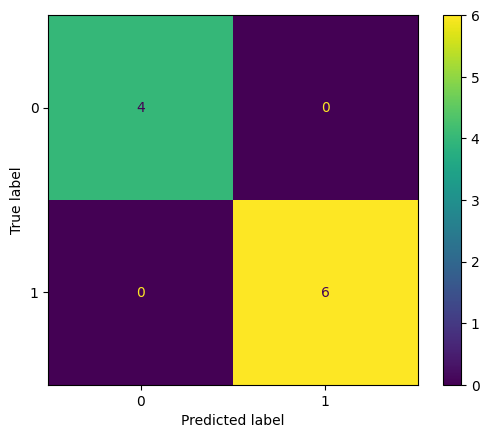

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.savefig("confusion_matrix.png")
plt.show()

## Confusion Matrix Analysis

The confusion matrix visualizes the model's prediction performance and shows the number of correct and incorrect classifications.

In [ ]:
joblib.dump(model,"model.pkl")

print("Model Saved")

Model Saved


## Model Deployment Preparation

The trained model was saved using Joblib. Saving the model allows it to be reused in external applications without retraining.

In [ ]:
from google.colab import files

files.download("student_data.csv")
files.download("model.pkl")
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 123.5 MB/s eta 0:00:00


In [ ]:
import streamlit as st

## Streamlit Application Development

A Streamlit application was created to provide an interactive interface where users can enter student information and receive predictions in real time.

In [1]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("model.pkl")

st.title("Student Pass Prediction")

st.write(
    "This app uses a Machine Learning model to predict whether a student will pass based on Age, Study Hours, and Attendance."
)

age = st.number_input("Age",18,30)
study = st.number_input("Study Hours",1,10)
attendance = st.number_input("Attendance",50,100)

if st.button("Predict"):
    data = pd.DataFrame(
        [[age,study,attendance]],
        columns=["Age","StudyHours","Attendance"]
    )

    result = model.predict(data)

    st.success(f"Prediction: {result[0]}")

Writing app.py


In [ ]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib
numpy
matplotlib

Writing requirements.txt


In [ ]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

A Random Forest Classifier was successfully trained, evaluated, and deployed using Streamlit.

The project demonstrates the complete machine learning workflow, including data preparation, model training, evaluation, model saving, and deployment through an interactive web application.

The deployed system allows users to predict student pass outcomes quickly and efficiently.